In [36]:
import sys
import os

# Make sure the notebook can find the source code in the src folder
sys.path.append(os.path.abspath('../'))
from src.data_loader import download_stock_data

# List of selected stocks: all current OMXS30 constituents
omxs30_tickers = [
    'ABB.ST', 'ADDT-B.ST', 'ALFA.ST', 'ASSA-B.ST', 'AZN.ST',
    'ATCO-A.ST', 'BOL.ST', 'EPI-A.ST', 'EQT.ST', 'ERIC-B.ST',
    'ESSITY-B.ST', 'EVO.ST', 'SHB-A.ST', 'HM-B.ST', 'HEXA-B.ST',
    'INDU-C.ST', 'INVE-B.ST', 'LIFCO-B.ST', 'NIBE-B.ST', 'NDA-SE.ST',
    'SAAB-B.ST', 'SAND.ST', 'SCA-B.ST', 'SEB-A.ST', 'SKA-B.ST',
    'SKF-B.ST', 'SWED-A.ST', 'TEL2-B.ST', 'TELIA.ST', 'VOLV-B.ST'
 ]

# Run the function and fetch the data
df_prices = download_stock_data(
    tickers=omxs30_tickers, 
    start_date='2015-01-01', 
    end_date='2026-01-01'
 )

# Show the first 20 rows of the new price history
df_prices.head(20)

[********************* 43%                       ]  13 of 30 completed

Fetching data for 30 assets from Yahoo Finance...


[*********************100%***********************]  30 of 30 completed


Ticker,ABB.ST,ADDT-B.ST,ALFA.ST,ASSA-B.ST,ATCO-A.ST,AZN.ST,BOL.ST,EPI-A.ST,EQT.ST,ERIC-B.ST,...,SAND.ST,SCA-B.ST,SEB-A.ST,SHB-A.ST,SKA-B.ST,SKF-B.ST,SWED-A.ST,TEL2-B.ST,TELIA.ST,VOLV-B.ST
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-02,153.346924,20.768126,116.762260,112.851387,31.207472,517.489868,83.672028,NaN,NaN,67.695740,...,54.751968,20.850052,49.862488,51.403088,103.896446,112.249359,85.793816,37.662498,25.140524,46.302258
2015-01-05,151.868896,20.816534,114.624931,115.180199,31.150076,521.682007,84.134315,NaN,NaN,67.910759,...,54.176388,20.713692,49.285038,50.940754,104.143524,112.727310,85.264496,37.563442,24.935396,45.949627
2015-01-07,146.972885,20.768126,111.300171,111.371925,30.274841,501.187317,82.549370,NaN,NaN,67.229866,...,52.521599,20.217854,47.326683,49.833946,103.649361,109.245110,83.058998,37.523819,24.615202,45.678379
2015-01-08,150.575623,21.058586,114.466614,114.248657,31.322260,517.489868,85.785294,NaN,NaN,70.132637,...,53.492897,20.974007,47.703285,50.408371,106.552528,112.522469,82.573784,37.068134,25.665848,47.305866
2015-01-09,148.358551,20.913355,111.300171,114.385696,31.293558,519.818726,87.436287,NaN,NaN,69.810120,...,52.881340,20.887236,46.950081,49.455673,105.811317,112.795570,81.382812,36.949261,25.290613,47.360123
2015-01-12,148.820419,20.913355,109.716942,117.317245,31.566177,531.929321,86.775879,NaN,NaN,70.598534,...,53.097183,21.073175,47.050507,49.875988,107.417305,114.365974,81.603371,36.969082,25.465727,48.282364
2015-01-13,147.804291,21.881565,109.241982,118.440529,31.580524,537.518738,87.238167,NaN,NaN,69.774277,...,53.744709,21.432661,46.975193,50.842674,108.529160,118.257858,82.265030,37.761566,25.840956,49.367363
2015-01-14,143.739624,21.397463,107.579605,115.399376,30.662233,533.792480,74.294426,NaN,NaN,69.451744,...,51.262531,21.234322,46.397728,49.679844,106.614319,116.482590,80.456512,37.424751,25.515749,47.983990
2015-01-15,149.467072,21.542694,109.796089,118.248741,31.164425,542.176697,76.473724,NaN,NaN,69.666748,...,52.197838,21.556620,47.602871,50.254257,108.467392,118.326096,80.765289,37.761566,25.815939,49.150360


In [37]:
%pip install optuna


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [38]:
%load_ext autoreload
%autoreload 2

import sys
import os

# This line tells Python to look in the folder above this notebook
sys.path.append(os.path.abspath('../'))

from src.data_loader import download_stock_data, download_macro_and_market_data, get_data_path

# 1. Fetch stock data
omxs30_tickers = [
    'ABB.ST', 'ADDT-B.ST', 'ALFA.ST', 'ASSA-B.ST', 'AZN.ST',
    'ATCO-A.ST', 'BOL.ST', 'EPI-A.ST', 'EQT.ST', 'ERIC-B.ST',
    'ESSITY-B.ST', 'EVO.ST', 'SHB-A.ST', 'HM-B.ST', 'HEXA-B.ST',
    'INDU-C.ST', 'INVE-B.ST', 'LIFCO-B.ST', 'NIBE-B.ST', 'NDA-SE.ST',
    'SAAB-B.ST', 'SAND.ST', 'SCA-B.ST', 'SEB-A.ST', 'SKA-B.ST',
    'SKF-B.ST', 'SWED-A.ST', 'TEL2-B.ST', 'TELIA.ST', 'VOLV-B.ST'
 ]
df_prices = download_stock_data(tickers=omxs30_tickers, start_date='2015-01-01', end_date='2026-01-01')
df_monthly_returns = df_prices.resample('ME').last().pct_change().dropna()

# 2. Fetch all macro and market data
df_global_data = download_macro_and_market_data(start_date='2015-01-01', end_date='2026-01-01')
df_monthly_global = df_global_data.resample('ME').last()

# 3. Show the first rows of the macro data
df_monthly_global.head()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Fetching data for 30 assets from Yahoo Finance...


[*********************100%***********************]  30 of 30 completed
[*********************100%***********************]  8 of 8 completed

Fetching global market and macro data (VIX, rates, currencies, commodities, indices)...


Ticker,Brent_Oil,EURSEK,Copper,USDSEK,SP500,OMXS30_Index,US10Y,VIX
Date,,,,,,,,
2015-01-31,52.990002,9.3625,2.5280,8.26040,1994.989990,1573.619995,1.675,20.969999
2015-02-28,62.580002,9.4023,2.7160,8.39220,2104.500000,1691.030029,2.002,13.340000
2015-03-31,55.110001,9.3018,2.7470,8.58890,2067.889893,1667.729980,1.934,15.290000
2015-04-30,66.779999,9.2690,2.8865,8.34131,2085.510010,1628.040039,2.046,14.550000
2015-05-31,65.559998,9.2674,2.7595,8.45560,2107.389893,1644.989990,2.095,13.840000


In [39]:
# 1. Install the package required for Excel export directly in the cell
!pip3 install openpyxl

# 2. Merge stock returns and macro data on date
df_combined = df_monthly_returns.join(df_monthly_global, how='inner')

# 3. Export to Excel (the file will be saved in your project folder)
df_combined.to_excel(get_data_path('omxs30_och_makrodata.xlsx'))

print("Done! The file 'omxs30_och_makrodata.xlsx' has been created in data/.")


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Done! The file 'omxs30_och_makrodata.xlsx' has been created in data/.


In [40]:
import pandas as pd
import numpy as np
from src.data_loader import get_data_path

# 1. Create the shifted target variable as next month's relative return
# Relative return = stock return - OMXS30 return
omxs30_return_next = df_monthly_global['OMXS30_Index'].pct_change().shift(-1)
df_target = df_monthly_returns.shift(-1).sub(omxs30_return_next, axis=0)

# 2. Create stock-specific rolling features
df_momentum_3M = df_monthly_returns.rolling(3).sum()
df_volatility_3M = df_monthly_returns.rolling(3).std()
df_omxs30_momentum_3M = df_monthly_global['OMXS30_Index'].pct_change().rolling(3).sum()

# 3. Transform the stock target from wide to long format
df_target_long = df_target.reset_index().melt(
    id_vars='Date', 
    var_name='Ticker', 
    value_name='Target_Next_Month_Relative_Return'
)

# 4. Transform momentum 1M to 12M into long format and merge them
momentum_feature_frames = []
for months in range(1, 13):
    df_momentum_month = df_monthly_returns.rolling(months).sum()
    df_momentum_long = df_momentum_month.reset_index().melt(
        id_vars='Date', 
        var_name='Ticker', 
        value_name=f'Feature_Momentum_{months}M'
    )
    momentum_feature_frames.append(df_momentum_long)

df_stock_features_long = momentum_feature_frames[0]
for df_feature in momentum_feature_frames[1:]:
    df_stock_features_long = pd.merge(df_stock_features_long, df_feature, on=['Date', 'Ticker'])

# 5. Add 3M volatility
df_volatility_long = df_volatility_3M.reset_index().melt(
    id_vars='Date', 
    var_name='Ticker', 
    value_name='Feature_Volatility_3M'
 )

# 6. Add relative momentum and momentum x rate sensitivity
df_momentum_3M_long = df_momentum_3M.reset_index().melt(
    id_vars='Date', 
    var_name='Ticker', 
    value_name='Feature_Momentum_3M'
 )

df_omxs30_momentum_long = df_omxs30_momentum_3M.reset_index()
df_omxs30_momentum_long.columns = ['Date', 'OMXS30_Momentum_3M']

df_relative_momentum_long = pd.merge(df_momentum_3M_long, df_omxs30_momentum_long, on='Date', how='left')
df_relative_momentum_long['Feature_Relative_Momentum_3M'] = df_relative_momentum_long['Feature_Momentum_3M'] - df_relative_momentum_long['OMXS30_Momentum_3M']
df_relative_momentum_long = df_relative_momentum_long[['Date', 'Ticker', 'Feature_Relative_Momentum_3M']]

df_rate_sensitivity_long = pd.merge(
    df_momentum_3M_long[['Date', 'Ticker', 'Feature_Momentum_3M']],
    df_monthly_global.reset_index()[['Date', 'US10Y']],
    on='Date',
    how='left'
 )
df_rate_sensitivity_long['Feature_Mom3M_x_US10Y'] = df_rate_sensitivity_long['Feature_Momentum_3M'] * df_rate_sensitivity_long['US10Y']
df_rate_sensitivity_long = df_rate_sensitivity_long[['Date', 'Ticker', 'Feature_Mom3M_x_US10Y']]

# 7. Merge all stock-specific features together
df_stocks_long = pd.merge(df_target_long, df_stock_features_long, on=['Date', 'Ticker'])
df_stocks_long = pd.merge(df_stocks_long, df_volatility_long, on=['Date', 'Ticker'])
df_stocks_long = pd.merge(df_stocks_long, df_relative_momentum_long, on=['Date', 'Ticker'])
df_stocks_long = pd.merge(df_stocks_long, df_rate_sensitivity_long, on=['Date', 'Ticker'])

# 8. Merge with the macro data by date
df_macro_reset = df_monthly_global.reset_index()
df_panel = pd.merge(df_stocks_long, df_macro_reset, on='Date')

# 9. Remove rows with NaN values (at the start because of rolling windows, at the end because of the shift)
df_panel = df_panel.dropna().reset_index(drop=True)

# 10. Export the new structure to Excel
df_panel.to_excel(get_data_path('omxs30_paneldata_slutgiltig.xlsx'), index=False)

print(f"Done! The panel data has been created with a total of {df_panel.shape[0]} rows.")
print("Open data/omxs30_paneldata_slutgiltig.xlsx to review the result.")

Done! The panel data has been created with a total of 1890 rows.
Open data/omxs30_paneldata_slutgiltig.xlsx to review the result.


In [41]:
from sklearn.preprocessing import StandardScaler

# 1. Ensure the date column has the correct format
df_panel['Date'] = pd.to_datetime(df_panel['Date'])

# 2. Create a time split (train through 2022, test from 2023 onward)
train_mask = df_panel['Date'] < '2023-01-01'
test_mask = df_panel['Date'] >= '2023-01-01'

df_train = df_panel[train_mask].copy()
df_test = df_panel[test_mask].copy()

# 3. Define which columns are features (X) and which one is the target (y)
feature_cols = [
    'Feature_Momentum_1M',
    'Feature_Momentum_2M',
    'Feature_Momentum_3M',
    'Feature_Momentum_4M',
    'Feature_Momentum_5M',
    'Feature_Momentum_6M',
    'Feature_Momentum_7M',
    'Feature_Momentum_8M',
    'Feature_Momentum_9M',
    'Feature_Momentum_10M',
    'Feature_Momentum_11M',
    'Feature_Momentum_12M',
    'Feature_Volatility_3M',
    'Feature_Relative_Momentum_3M',
    'Feature_Mom3M_x_US10Y',
    'VIX',
    'US10Y',
    'USDSEK', 
    'EURSEK',
    'Copper',
    'Brent_Oil',
    'SP500',
    'OMXS30_Index'
 ]
target_col = 'Target_Next_Month_Relative_Return'

# 4. Initialize the scaling tool (StandardScaler shifts to mean 0 and standard deviation 1)
scaler = StandardScaler()

# 5. Fit the tool on the training data and transform it
df_train[feature_cols] = scaler.fit_transform(df_train[feature_cols])

# 6. Transform the test data with exactly the same rules (use only .transform, not .fit_transform)
df_test[feature_cols] = scaler.transform(df_test[feature_cols])

print(f"The data has been split and normalized!")
print(f"Training data (2015-2022): {df_train.shape[0]} rows")
print(f"Test data (2023-2026): {df_test.shape[0]} rows")

# Show what the scaled training data looks like now
df_train.head()

The data has been split and normalized!
Training data (2015-2022): 840 rows
Test data (2023-2026): 1050 rows


,Date,Ticker,Target_Next_Month_Relative_Return,Feature_Momentum_1M,Feature_Momentum_2M,Feature_Momentum_3M,Feature_Momentum_4M,Feature_Momentum_5M,Feature_Momentum_6M,Feature_Momentum_7M,...,Feature_Relative_Momentum_3M,Feature_Mom3M_x_US10Y,Brent_Oil,EURSEK,Copper,USDSEK,SP500,OMXS30_Index,US10Y,VIX
0,2020-09-30,ABB.ST,0.005256,0.307022,0.175964,0.377430,1.044300,0.750762,0.882903,0.081322,...,-0.167838,0.038254,-1.786372,0.424382,-1.979131,-0.350026,-1.891664,-1.420837,-1.356412,0.428591
1,2020-10-31,ABB.ST,-0.072031,-0.750670,-0.356259,-0.346089,-0.099825,0.498644,0.289680,0.515560,...,-0.285873,-0.182598,-1.945492,0.045827,-1.948091,-0.407827,-2.136551,-2.029019,-1.172391,2.434708
2,2020-11-30,ABB.ST,0.035595,0.345191,-0.327063,-0.084810,-0.106739,0.064773,0.542351,0.404065,...,-0.657401,-0.084679,-1.483633,-0.731785,-1.167953,-0.876864,-1.210934,-0.941277,-1.188481,-0.570163
3,2020-12-31,ABB.ST,0.038230,0.005220,0.251117,-0.281920,-0.071955,-0.108661,0.014625,0.502783,...,-0.407650,-0.157862,-1.291686,-1.030765,-0.974471,-1.222972,-0.857080,-1.174147,-1.115074,-0.194769
4,2021-01-31,ABB.ST,-0.051212,0.710085,0.530224,0.672116,0.161396,0.268328,0.167256,0.294501,...,-0.137010,0.304438,-1.105666,-0.921208,-0.851346,-1.048884,-0.967179,-0.771249,-0.938093,1.585767


In [42]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

# 1. Separate features (X) and target (y) for both training and test
X_train = df_train[feature_cols]
y_train = df_train[target_col]

X_test = df_test[feature_cols]
y_test = df_test[target_col]

# 2. Create and train the model (alpha is the regularization strength)
model = Ridge(alpha=1.0)
model.fit(X_train, y_train)

# 3. Make predictions on both the training and test data
df_train['Predicted_Return'] = model.predict(X_train)
df_test['Predicted_Return'] = model.predict(X_test)

# 4. Evaluate the model with basic metrics
print("--- TRAINING PERFORMANCE Ridge (In-Sample) ---")
print(f"R2-score: {r2_score(y_train, df_train['Predicted_Return']):.4f}")
print(f"MSE: {mean_squared_error(y_train, df_train['Predicted_Return']):.6f}")

print("\n--- TEST PERFORMANCE Ridge (Out-of-Sample) ---")
print(f"R2-score: {r2_score(y_test, df_test['Predicted_Return']):.4f}")
print(f"MSE: {mean_squared_error(y_test, df_test['Predicted_Return']):.6f}")

# 5. Save the test results to Excel so you can compare predictions against the ground truth
df_test[['Date', 'Ticker', 'Target_Next_Month_Relative_Return', 'Predicted_Return']].to_excel(get_data_path('omxs30_modell_gissningar.xlsx'), index=False)
print("\nDone! The predictions have been saved to 'omxs30_modell_gissningar.xlsx'.")

--- TRAINING PERFORMANCE Ridge (In-Sample) ---
R2-score: 0.0737
MSE: 0.005241

--- TEST PERFORMANCE Ridge (Out-of-Sample) ---
R2-score: -0.7971
MSE: 0.006930

Done! The predictions have been saved to 'omxs30_modell_gissningar.xlsx'.


In [43]:
from sklearn.ensemble import RandomForestRegressor

# 1. Create and configure the model (we add limits to reduce overfitting)
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=3,
    min_samples_leaf=40,
    random_state=42,
    n_jobs=-1
)

# 2. Train the model
rf_model.fit(X_train, y_train)

# 3. Make predictions
df_train['RF_Predicted_Return'] = rf_model.predict(X_train)
df_test['RF_Predicted_Return'] = rf_model.predict(X_test)

# 4. Evaluate
print("--- RANDOM FOREST: TRAINING PERFORMANCE ---")
print(f"R2-score: {r2_score(y_train, df_train['RF_Predicted_Return']):.4f}")

print("\n--- RANDOM FOREST: TEST PERFORMANCE ---")
print(f"R2-score: {r2_score(y_test, df_test['RF_Predicted_Return']):.4f}")

# 5. Save the Random Forest predictions to Excel
df_test[['Date', 'Ticker', 'Target_Next_Month_Relative_Return', 'RF_Predicted_Return']].to_excel(get_data_path('omxs30_modell_gissningar.xlsx'), index=False)
print("\nDone! The Random Forest predictions have been saved to 'omxs30_modell_gissningar.xlsx'.")

--- RANDOM FOREST: TRAINING PERFORMANCE ---
R2-score: 0.0823

--- RANDOM FOREST: TEST PERFORMANCE ---
R2-score: -0.0242

Done! The Random Forest predictions have been saved to 'omxs30_modell_gissningar.xlsx'.


In [44]:
import optuna
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score
import numpy as np

# Stäng av Optunas spam-loggar
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    # Begränsad sökrymd för att tvinga fram hård regularisering
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 250),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.03),
        'max_depth': trial.suggest_int('max_depth', 1, 3), # Max 3 för att stoppa overfitting
        'min_child_weight': trial.suggest_int('min_child_weight', 40, 80),
        'subsample': trial.suggest_float('subsample', 0.5, 0.7),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.7),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.5, 3.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 2.0, 10.0),
        'random_state': 42,
        'n_jobs': -1
    }
    
    # 4-faldig korsvalidering över tid
    tscv = TimeSeriesSplit(n_splits=4)
    scores = []
    
    for train_idx, val_idx in tscv.split(X_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        model = XGBRegressor(**params)
        model.fit(X_tr, y_tr)
        
        preds = model.predict(X_val)
        
        # Vi ber Optuna maximera traditionellt R2-score denna gång
        score = r2_score(y_val, preds)
        scores.append(score)
            
    return np.mean(scores)

# Starta sökningen
study = optuna.create_study(direction='maximize')
print("Kör Optuna för att maximera R2 (begränsad sökrymd)...")
study.optimize(objective, n_trials=40)

print("\n--- OPTIMERING KLAR ---")
print(f"Bästa validerings-R2: {study.best_value:.4f}")
print("\nBästa parametrar (Kopiera dessa till din slutgiltiga modell):")
for key, value in study.best_params.items():
    print(f"    {key}={value},")

Kör Optuna för att maximera R2 (begränsad sökrymd)...

--- OPTIMERING KLAR ---
Bästa validerings-R2: -0.0032

Bästa parametrar (Kopiera dessa till din slutgiltiga modell):
    n_estimators=161,
    learning_rate=0.006680702933513272,
    max_depth=2,
    min_child_weight=40,
    subsample=0.5292527905797956,
    colsample_bytree=0.5369346929214202,
    reg_alpha=0.6564562389179961,
    reg_lambda=4.800011905986055,


In [45]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score

# 1. Konfigurera XGBoost med Optunas bästa parametrar
xgb_model = XGBRegressor(
    n_estimators=105,
    learning_rate=0.0170143,
    max_depth=1,
    min_child_weight=41,
    subsample=0.5078,
    colsample_bytree=0.6646,
    reg_alpha=0.5695,
    reg_lambda=9.8708,
    random_state=42,
    n_jobs=-1
)

# 2. Träna modellen på hela träningsdatan
xgb_model.fit(X_train, y_train)

# 3. Gör prediktioner
df_train['XGB_Predicted_Return'] = xgb_model.predict(X_train)
df_test['XGB_Predicted_Return'] = xgb_model.predict(X_test)

# 4. Utvärdera slutgiltig prestanda
print("--- SLUTGILTIG OPTIMERAD XGBOOST ---")
print(f"Tränings R2 (In-Sample): {r2_score(y_train, df_train['XGB_Predicted_Return']):.4f}")
print(f"Test R2 (Out-of-Sample): {r2_score(y_test, df_test['XGB_Predicted_Return']):.4f}")

# 5. Spara de stabila gissningarna till Excel för ditt backtest
df_test[['Date', 'Ticker', 'Target_Next_Month_Relative_Return', 'XGB_Predicted_Return']].to_excel(
    get_data_path('omxs30_modell_gissningar.xlsx')
)
print("\nKlart! De optimerade gissningarna har sparats till Excel.")

--- SLUTGILTIG OPTIMERAD XGBOOST ---
Tränings R2 (In-Sample): 0.0266
Test R2 (Out-of-Sample): -0.0061

Klart! De optimerade gissningarna har sparats till Excel.


In [46]:

# 1. Hämta betydelsen av varje feature från din tränade modell
importances = rf_model.feature_importances_
feature_names = X_train.columns

# 2. Skapa en tabell och sortera med den viktigaste överst
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 3. Skriv ut resultatet
print("--- MODELLENS VIKTIGASTE FEATURES ---")
print(importance_df.to_string(index=False))

--- MODELLENS VIKTIGASTE FEATURES ---
                     Feature  Importance
         Feature_Momentum_2M    0.155559
         Feature_Momentum_3M    0.144755
Feature_Relative_Momentum_3M    0.106559
         Feature_Momentum_4M    0.082500
         Feature_Momentum_5M    0.058981
                         VIX    0.045655
         Feature_Momentum_1M    0.043554
         Feature_Momentum_6M    0.042745
        Feature_Momentum_10M    0.039188
                   Brent_Oil    0.031896
       Feature_Volatility_3M    0.030767
        Feature_Momentum_12M    0.030285
        Feature_Momentum_11M    0.029901
       Feature_Mom3M_x_US10Y    0.027227
         Feature_Momentum_8M    0.021461
                       SP500    0.020811
         Feature_Momentum_9M    0.020317
                      USDSEK    0.017859
         Feature_Momentum_7M    0.012752
                       US10Y    0.012020
                      EURSEK    0.009683
                OMXS30_Index    0.008677
                   

In [47]:
# 1. Hämta betydelsen av varje feature från din tränade modell
importances = xgb_model.feature_importances_
feature_names = X_train.columns

# 2. Skapa en tabell och sortera med den viktigaste överst
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 3. Skriv ut resultatet
print("--- MODELLENS VIKTIGASTE FEATURES ---")
print(importance_df.to_string(index=False))

--- MODELLENS VIKTIGASTE FEATURES ---
                     Feature  Importance
                       SP500    0.074435
         Feature_Momentum_3M    0.071088
         Feature_Momentum_2M    0.068869
         Feature_Momentum_8M    0.064290
Feature_Relative_Momentum_3M    0.061619
        Feature_Momentum_12M    0.056991
                      USDSEK    0.054943
       Feature_Mom3M_x_US10Y    0.053339
         Feature_Momentum_4M    0.053178
         Feature_Momentum_6M    0.049803
                      Copper    0.047855
        Feature_Momentum_11M    0.045301
                OMXS30_Index    0.044259
         Feature_Momentum_1M    0.043608
                         VIX    0.042976
                      EURSEK    0.042529
        Feature_Momentum_10M    0.040511
       Feature_Volatility_3M    0.031795
                       US10Y    0.028893
         Feature_Momentum_5M    0.023719
         Feature_Momentum_9M    0.000000
         Feature_Momentum_7M    0.000000
                   

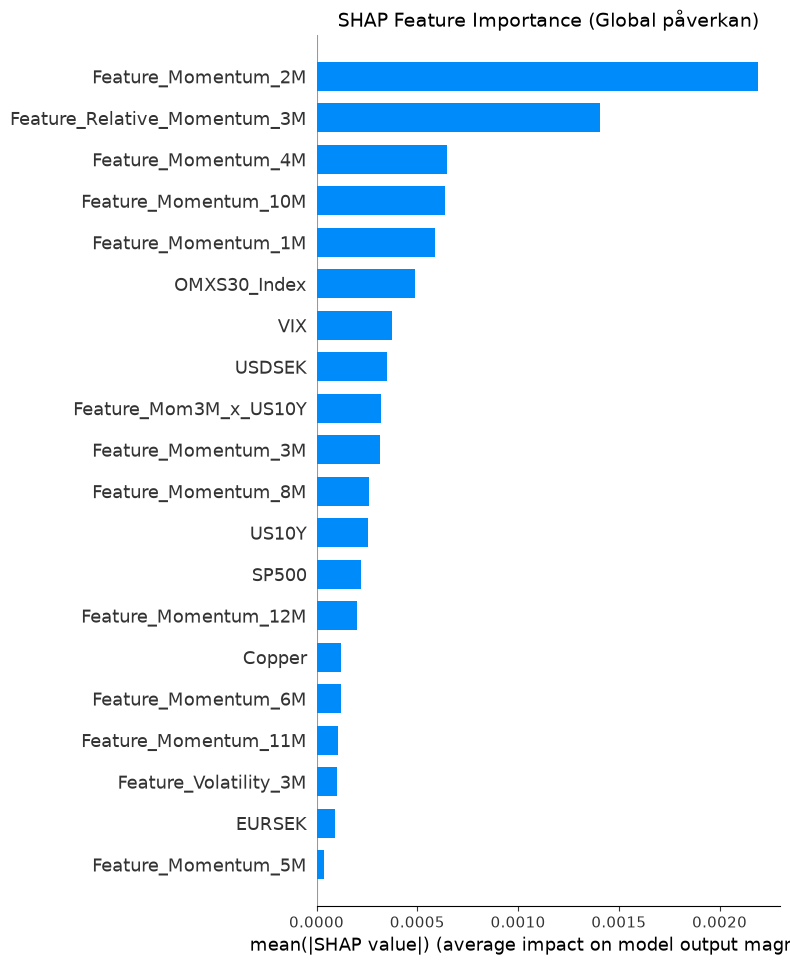

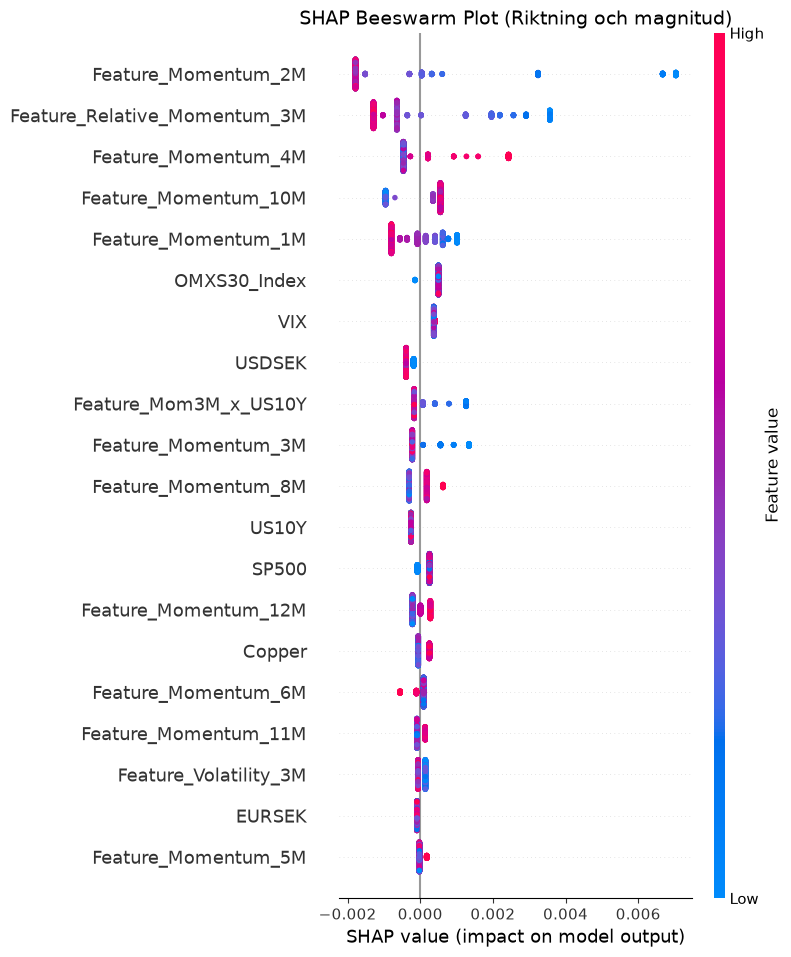

In [48]:
import shap
import matplotlib.pyplot as plt

# 1. Initiera SHAP TreeExplainer med din tränade XGBoost-modell
explainer = shap.TreeExplainer(xgb_model)

# 2. Beräkna SHAP-värden för testdatan (X_test) för att se hur modellen agerar på osedd data
shap_values = explainer.shap_values(X_test)

# 3. Skapa en Summary Plot (Beeswarm-diagram)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Global påverkan)", fontsize=14)
plt.show()

# 4. Skapa en detaljerad Beeswarm-plot för att se riktning (positiv/negativ effekt)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Beeswarm Plot (Riktning och magnitud)", fontsize=14)
plt.show()